## ==============================================================================
## Project Title: New York Times Analysis
This project analyzes quarterly coverage trends and potential media bias in the New York Times across three distinct topics: New Year, Zoom Platform, and GPT Models.

By crossing-referencing article text with sentiment data, the project evaluates both the volume of coverage and the emotional framing (positive vs. negative) associated with each topic over time.

## Data & Methodology:
- Primary Dataset (data/nyt_articles.txt): Used to isolate target topics and track their mention frequency on a quarterly basis.
- Secondary Dataset (data/nyt_sentiments.csv): Contains pre-evaluated sentiment scores (determined by a sentiment model) for each article's leading paragraph, allowing us to calculate the proportion of positive vs. negative coverage for each topic and identify potential journalistic bias.
## ==============================================================================

## 1. Import Libraries

In [52]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure that pandas shows at least 280 characters in columns, so we can see full articles.
pd.set_option("max_colwidth", 280)
plt.style.use("fivethirtyeight")
sns.set()
sns.set_context("talk")
sns.set_palette("colorblind")

## 2. Data Loading

In [53]:
#Primary dataset that we will perform majority of preprocessing happens
news_df = pd.read_json('data/nyt_articles.txt')
news_df.head(3)

,web_url,pub_date,lead_paragraph
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do."
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne..."


In [54]:
#Second pre-made dataset for further analysis
sentiment = pd.read_csv("data/nyt_sentiments.csv")

## 3. Using regular expression to transform data into usable columns

In [55]:
pattern = r"([0-9]{4})-([0-9]{2})-[0-9]{2}T[0-9]{2}:([0-9]{2}):[0-9]{2}\+[0-9]{4}"
dates = (
    news_df["pub_date"]
    .str.extract(pattern)
    .rename(columns={0:"Year", 1:"Month", 2:"Minute"}).astype(int)
) 

dates.head()

,Year,Month,Minute
0,2020,1,0
1,2020,1,42
2,2020,1,0
3,2020,1,40
4,2020,1,20


In [56]:
news_df_dates = news_df.merge(right=dates, left_index=True, right_index=True)
news_df_dates.head(3)

,web_url,pub_date,lead_paragraph,Year,Month,Minute
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.,2020,1,42
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne...",2020,1,0


In [57]:
NewYearPattern = r"\bNew Year('s)?\b"
ZoomPattern = r"\bZoom\b"
GPTPattern = r"\b[A-Za-z]+-?GPT\b"

topic_pattern_map = {
    "New Year": NewYearPattern,
    "Zoom": ZoomPattern,
    "GPT Model": GPTPattern,
}

for topic, regex_pattern in topic_pattern_map.items():
    news_df_dates[topic] = (
        news_df_dates["lead_paragraph"]
        .str.findall(regex_pattern)
        .str.len()
    )

news_df_dates.head(1)

,web_url,pub_date,lead_paragraph,Year,Month,Minute,New Year,Zoom,GPT Model
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0,1,0,0


## More data transformation

In [58]:
quarter_num = (news_df_dates["Month"] - 1) // 3 + 1
news_df_dates['Quarter'] = news_df_dates["Year"].astype(str) + "Q" + quarter_num.astype(str)
news_df_dates.head(3)

,web_url,pub_date,lead_paragraph,Year,Month,Minute,New Year,Zoom,GPT Model,Quarter
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0,1,0,0,2020Q1
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.,2020,1,42,1,0,0,2020Q1
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne...",2020,1,0,1,0,0,2020Q1


## 4. Data Manipulation and Visualization

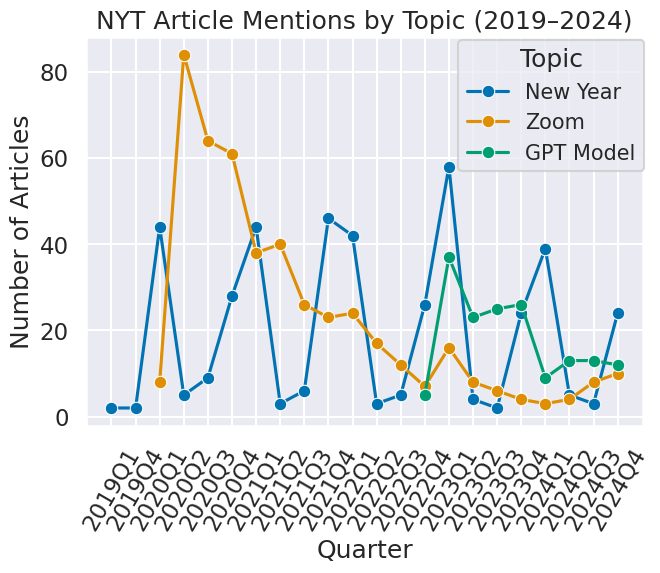

In [59]:
#count articles mentioning New Year
new_year = (
    news_df_dates[news_df_dates["New Year"] > 0]
    .groupby("Quarter")
    .size()
    .reset_index(name="Number of Articles")
)
new_year["Topic"] = "New Year"

#count articles mentioning Zoom
zoom = (
    news_df_dates[news_df_dates["Zoom"] > 0]
    .groupby("Quarter")
    .size()
    .reset_index(name="Number of Articles")
)
zoom["Topic"] = "Zoom"

#count articles mentioning GPT Model
gpt = (
    news_df_dates[news_df_dates["GPT Model"] > 0]
    .groupby("Quarter")
    .size()
    .reset_index(name="Number of Articles")
)
gpt["Topic"] = "GPT Model"

#combine the three datasets
plot_df = pd.concat([new_year, zoom, gpt], ignore_index=True)

# visualize grouped line plot
sns.lineplot(
    data=plot_df,
    x="Quarter",
    y="Number of Articles",
    hue="Topic",
    marker="o"
)

plt.xticks(rotation=60)
plt.yticks()
plt.ylabel("Number of Articles")
plt.xlabel("Quarter")
plt.title("NYT Article Mentions by Topic (2019–2024)")
plt.gcf().set_facecolor('white')
plt.legend(title='Topic', loc='upper right', bbox_to_anchor=(1.02, 1.02), fontsize = 'small')
plt.show()

### Evaluation of the Visualization

For the GPT Model topic, it isn't until 2024Q4 when the first instance of an article mention occurs, likely due to the fact that ChatGpt became public and popularized around that time period, and wasn't well known before it. For the Zoom topic, there is a peak in the number of articles mentioning it in 2020Q2, before the number of articles starts to drop during the following quarters. This is likely due to the fact that Zoom was popularized during the height of the Covid-19 Pandemic when digital activity/meeting demand was high, and gradually became less relevant as the quarantine ended and people returned to in-person activities/meetings. The New Year topic fluctuates, hitting a local or all time peak during approximately quarters 3, 4, and 1, and drops and hits a local or all time low during approximately quarter 2 of every year. This is likely due to the fact that quarters 3, 4, and 1 are the nearest time points to New Years Day when the topic is relatively relevant, compared to quarter 2 which may likely be around the half year mark when it is farthest away from the New Year Day. 

## Transforming and filtering the second dataset

In [60]:
sentiment = pd.read_csv("data/nyt_sentiments.csv")

sentiment["article_sentiment"] = (
    (2*(sentiment["label"] == "POSITIVE") - 1) * sentiment["score"]
)
news_df_sentiment2 = news_df_dates.merge(sentiment, on="web_url")
news_df_sentiment = news_df_sentiment2.drop(columns=["label", "score"])
news_df_sentiment.head(3)

,web_url,pub_date,lead_paragraph,Year,Month,Minute,New Year,Zoom,GPT Model,Quarter,article_sentiment
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0,1,0,0,2020Q1,0.986820
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.,2020,1,42,1,0,0,2020Q1,-0.992706
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne...",2020,1,0,1,0,0,2020Q1,-0.997801


In [61]:
news_df_filtered = news_df_sentiment[((news_df_sentiment['Zoom'] > 0) | news_df_sentiment['New Year'] > 0) | (news_df_sentiment['GPT Model'] > 0)]

In [62]:
news_df_filtered2 = news_df_filtered[['lead_paragraph', 'article_sentiment']]

top_positive = news_df_filtered2.sort_values(by = "article_sentiment", ascending = False).head(5).reset_index(drop = True)
top_negative = news_df_filtered2.sort_values(by = "article_sentiment", ascending = True).head(5).reset_index(drop = True)

display(top_positive, top_negative)

,lead_paragraph,article_sentiment
0,"Happy New Year, audiophiles!",0.999876
1,"It’s easy to think about Twyla Tharp and immediately picture her body of work. It’s impressive. Tharp has choreographed more than 150 dances for just about every surface and site imaginable: the concert stage, parks, Broadway, film, ice and now Zoom.",0.999872
2,"Merry Christmas, happy Hanukkah, joyous Kwanzaa and happy New Year.",0.999871
3,"Merry Christmas, happy Hanukkah, joyous Kwanzaa and happy New Year.",0.999871
4,Happy New Year!,0.999869


,lead_paragraph,article_sentiment
0,"The day after Labor Day has got to be one of the worst days in the American calendar year. (Not quite as bad as the first workday after New Year’s, but worth mentioning in the same breath.)",-0.999777
1,"One day this quarantine, who can say which, I encountered the following pieces of information: Zoom, the videoconferencing company, saw its stock hit a new high; Zūm, a ride-sharing venture, cut its work force by a third; and Zume, the robot pizza start-up, failed to raise mo...",-0.999759
2,"In the beginning there was Covid-19, and the tribe of the white collars rent their garments, for their workdays were a formless void, and all their rituals were gone. New routines came to replace the old, but the routines were scattered, and there was chaos around how best to...",-0.999729
3,"There’s a problem with leading artificial intelligence tools like ChatGPT, Gemini and Claude: We don’t really know how smart they are.",-0.999702
4,"I was in Brooklyn on a Zoom meeting in mid-March, when I saw my mom’s name come up on my cellphone. ""Your dad’s not feeling well,"" she said.",-0.999698


## Visualizing the second dataset

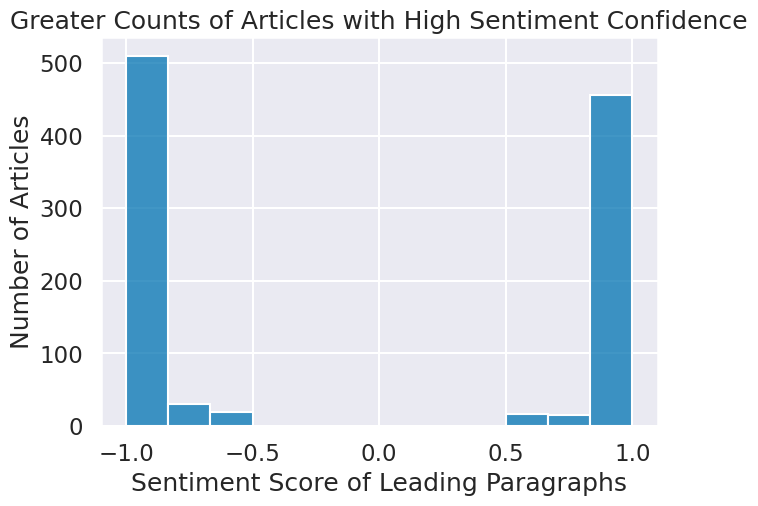

In [66]:
sns.histplot(data=news_df_filtered, x='article_sentiment')
plt.xlabel('Sentiment Score of Leading Paragraphs')
plt.ylabel('Number of Articles')
plt.title('Greater Counts of Articles with High Sentiment Confidence')
plt.plot();

### Evaluation of the Visualization

I am not very surprised by the unimodel and symmetric distribution of sentiment. It is expected that the closer the sentiment score is to the extremes (-1 and 1), the higher the article count will be because majority of the time, the sentiment model identifies a text's sentement with high confidence because majority of articles are written in a consistent tone siding in one direction (positive or negative). It is in the rare cases that an article is written in a truely ambiguous tone for the model's confidence to significantly go down, explaining why none of the articles received a 0 sentiment score

## Manipulating and visualizing second dataset

Text(0.5, 1.0, 'Greater % of Negative Sentiment Articles for Platform Topics')

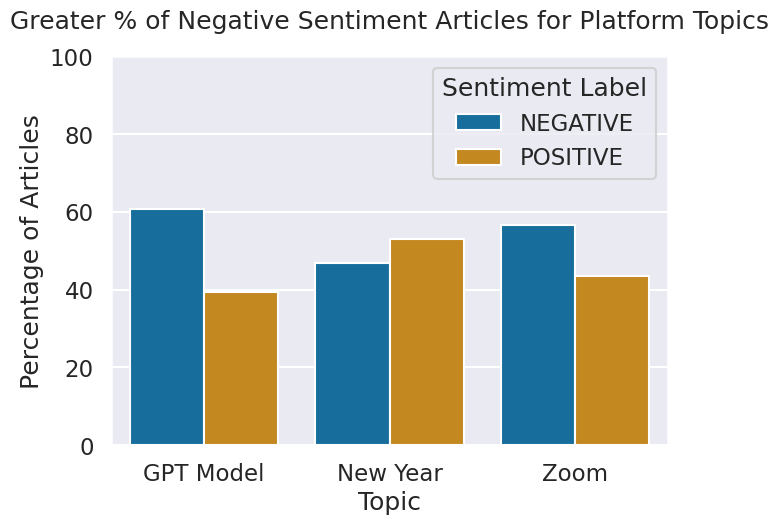

In [64]:
news_df_sentiment2 = news_df_sentiment2.rename(columns={"label": "Sentiment Label"})

#Transform new year, zoom, and gpt columns into a single column 'topic' 
sent_compare_df = (
    news_df_sentiment2
    .melt(
        id_vars=["web_url", "Quarter"],
        value_vars=["New Year", "Zoom", "GPT Model"],
        var_name="Topic",
        value_name="Count"
    )
    .query("Count > 0")
)
sent_compare_df

sent_compare_df = sent_compare_df[['web_url', 'Topic']]


#Merge with raw data
news_df_sentiment3 = news_df_sentiment2.merge(
    sent_compare_df,
    on=["web_url"],
    how="inner"
)

#group by sentiment label and topic
news_df_sentiment3 = news_df_sentiment3[['Sentiment Label', 'Topic']]
news_df_sentiment3 = news_df_sentiment3.groupby(['Sentiment Label', 'Topic']).size().reset_index(name='Count')

#find percentage of articles for each combination of label and topic
news_df_sentiment3["Percentage of Articles"] = (
    news_df_sentiment3["Count"]
    / news_df_sentiment3.groupby("Topic")["Count"].transform("sum")
    * 100
)

#visualize grouped bar plots
sns.barplot(
    data=news_df_sentiment3,
    x="Topic",
    y="Percentage of Articles",
    hue="Sentiment Label")

plt.ylim(0,100)
plt.title("Greater % of Negative Sentiment Articles for Platform Topics", pad=20)

### Evaluation of the Visualization

My definiton of a bias is the systematic favoring or disfavoring of a topic (GPT Model, New Year, Zoom) through significant differences in the proportions of articles with a positive sentiment or a negative sentiment. I agree with the hypothesis that there is a bias in the articles because there is a noticeable difference in the proportions of positive or negative sentinment articles across all three topics. As shown by the grouped bar chart, amongst the articles mentioning GPT Model, approximately 60% were classified by the DistilBERT model to have a negative sentiment while approximately 40% were classified to have a positive sentiment, showing a preference by the New York Times to post negative sentinment articles about GPT Model. This same idea applies to articles mentioning Zoom, where approximately 57% were classified to have a negative sentinment while approxiamtely 43% were classified to have a positive sentiment. While it could be argued that all articles (including all 3 topic mentions) have a higher proportion of articles that are classified to have a negative sentiment, the bar charts for the New Year topic say otherwise. With approximately 47% of the articles mentioning it being classified to have a negative sentinment while 53% being classified to have a positive sentiment, it shows a preference by the New York Times to post positive sentinment articles about the New Year topic, unlike the other two. With GPT Model and Zoom topics being the ones to face a higher proportion of negatively classified articles, it can be framed that the New York Times is specifically biased against the topic of technological platforms (like ChatGpt and Zoom). This issue proposes a major problem because New York Times readers are probabilistically more likely to read about GPT and Zoom-mentioning articles that carry a negative sentiment, which may lead to the public framing NYT to be biased against these topics. 